# k-Nearest Neighbors: CPU vs GPU Comparison

### Overview
In this notebook, we implement a k-Nearest Neighbors (kNN) using CuPy and compare its performance on CPU and GPU.

### Objectives
- Build a kNN model for classification
- Train and evaluate the model on CPU
- Train and evaluate the model on GPU
- Measure and compare:
  - Distances computation time
  - Precictions time
  - Accuracy

### Approach
- Use the same dataset and preprocessing for both CPU and GPU
- Evaluate model performance using accuracy

In [1]:
# ----------------------- Import required libraries ---------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import time
import math
import random

import torch
import cupy as cp

BLOCK_SIZE = 16

In [2]:
# ----------------------- Fix random seeds -----------------------
# Set random seeds for reproducibility
# This guarantees the same train/test split and model initialization,
# making results comparable between CPU and GPU runs

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [3]:
# Connection check to GPU and check if it's available
print(torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
!nvidia-smi

True
Sat Mar 28 09:39:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+

In [4]:
# ----------------------- Load dataset ----------------------

# Data address to run on localhost
# data = np.loadtxt('../data/MLoGPU_data3_train.csv', delimiter=',')

# Data address to run on Google Colab
data = np.loadtxt('/content/MLoGPU_data3_train.csv', delimiter=',')
X = data[:, :-1]
y = data[:, -1]

# Take all classes
classes = np.unique(y)
classes = classes.astype(int).tolist()

In [5]:
# Data splitting for CPU
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# Data splitting for GPU
X_train_cp = cp.array(X_train, dtype=cp.float32)
X_test_cp = cp.array(X_test, dtype=cp.float32)
y_train_cp = cp.array(y_train, dtype=cp.int32)
y_test_cp = cp.array(y_test, dtype=cp.int32)
print(X_train_cp.shape, X_test_cp.shape, y_train_cp.shape, y_test_cp.shape)

(3000, 7) (1000, 7) (3000,) (1000,)
(3000, 7) (1000, 7) (3000,) (1000,)


In [6]:
# Data normalization for CPU
mean_train = np.mean(X_train, axis=0)
std_train = np.std(X_train, axis=0)

X_train_norm = (X_train - mean_train) / std_train
X_test_norm = (X_test - mean_train) / std_train

# Data normalization for GPU
mean_train_cp = X_train_cp.mean()
std_train_cp = X_train_cp.std()

X_train_norm_cp = (X_train_cp - mean_train_cp) / std_train_cp
X_test_norm_cp = (X_test_cp - mean_train_cp) / std_train_cp

In [7]:
# No train needed for kNN

## CPU

In [8]:
# Compute distance of test point to all train points
def compute_distances(X_train, y_train, X_test_point):
    distances = []
    for i in range(len(X_train)):
        # Euclidean distance
        dist = np.sqrt(np.sum((np.array(X_train[i]) - np.array(X_test_point))**2))
        distances.append((dist, y_train[i]))

    # Sort by closest samples
    distances.sort(key=lambda x: x[0])
    return distances

In [9]:
start_time = time.time()

# Collect all test distances
dists = []
for i in range(len(X_test_norm)):
    dists.append(compute_distances(X_train_norm, y_train, X_test_norm[i]))

dists = np.array(dists)

# Execution time for computing distances
dists_time = time.time() - start_time
print(f'Execution time for calculationg distances on CPU: {dists_time:.6f}s')

Execution time for calculationg distances on CPU: 28.889162s


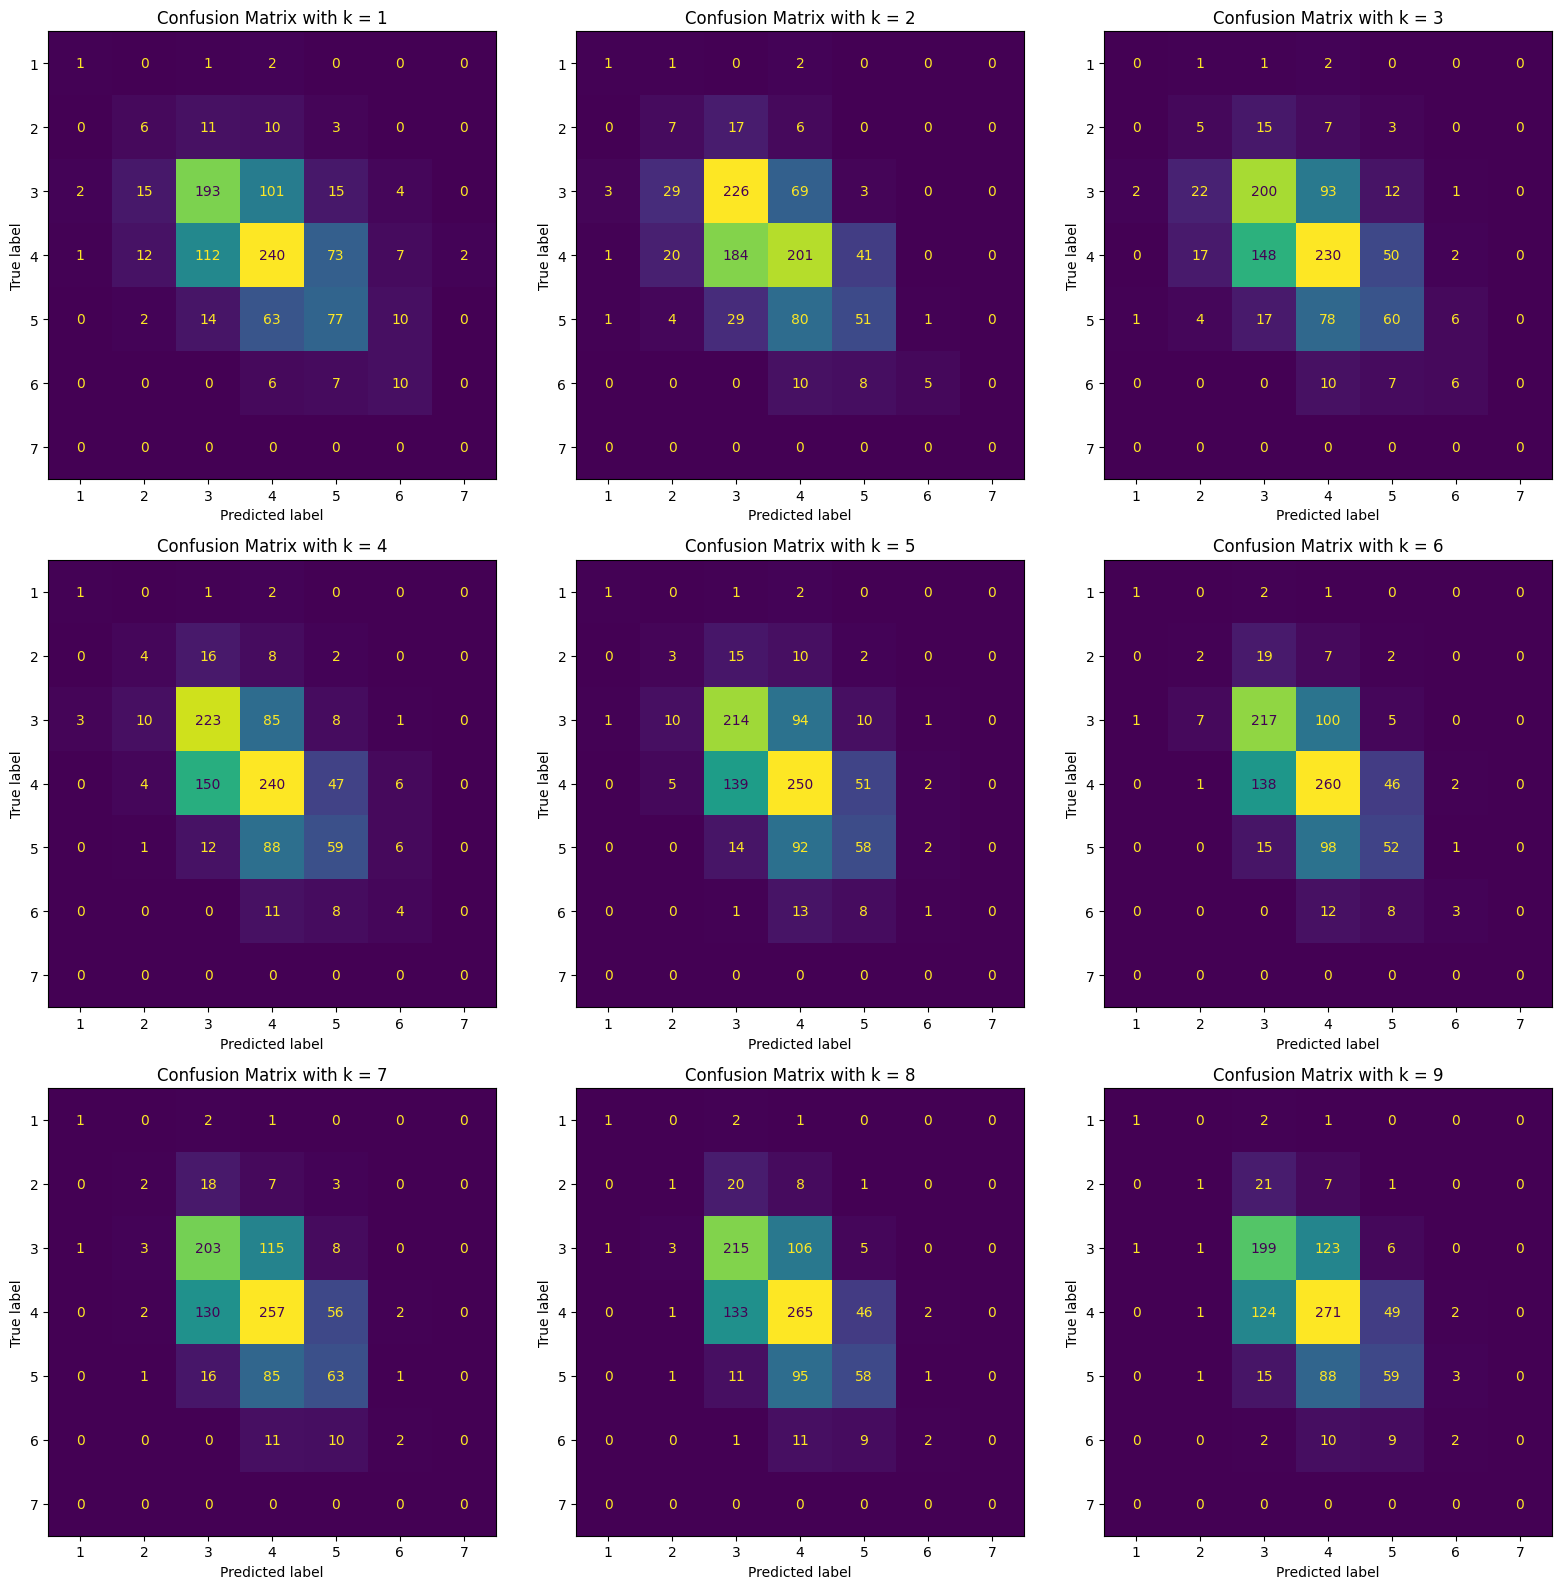

In [10]:
preds = np.zeros_like(y_test)
accuracies = []
exec_times = []
k_values = range(1, 10)

fig, axs = plt.subplots(3, 3, figsize=(16, 16))
axs = axs.ravel()

for K_VALUE in k_values:
    ax = axs[K_VALUE - 1]

    start_time = time.time()

    # Take nearest k train samples' labels for each test sample
    nearest_labels = dists[:, :K_VALUE, 1]

    # Compute mode for each test sample
    preds_res = stats.mode(nearest_labels, keepdims=True, axis=1)
    preds = np.array(preds_res)[0, ...]

    exec_times.append(time.time() - start_time)

    # Confusion matrix
    cm = confusion_matrix(y_test, preds, labels=classes)

    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix with k = {K_VALUE}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")


    accuracies.append(np.sum(np.trace(cm)) / len(preds) * 100)

plt.tight_layout()
plt.show()

In [11]:
# Average total execution time of kNN
total_exec_times = [t + dists_time for t in exec_times]
print(f"Execution time on CPU: {np.mean(total_exec_times):.6f} " + u"\u00B1" + f" {np.std(total_exec_times):.6f} s")

Execution time on CPU: 28.890187 ± 0.000253 s


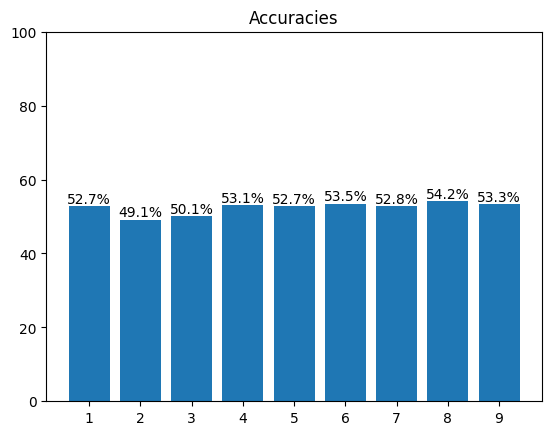

In [12]:
# Accuracies
accuracies_str = [f"{acc:.1f}%" for acc in accuracies]
fig, ax = plt.subplots()
bars = ax.bar(k_values, accuracies)
ax.bar_label(bars, labels=accuracies_str)
plt.title('Accuracies')
plt.xticks(k_values)
_, _ = plt.ylim((0,100))

## GPU

In [13]:
compute_distances = cp.RawKernel(r'''
extern "C" __global__
void compute_distances(
    const float* X_train, const float* X_test, float* distances,
    const int n_train, const int n_test, const int features
){
    int tId = blockIdx.x * blockDim.x + threadIdx.x;
    if (tId >= n_test) return;

    for (int i = 0; i < n_train; i++) {

        float dist = 0.0f;

        for (int j = 0; j < features; j++) {
            float diff = X_train[i * features + j] -
                         X_test[tId * features + j];
            dist += diff * diff;
        }

        distances[tId * n_train + i] = dist;
    }
}
''', 'compute_distances')

In [14]:
n_train = X_train_norm_cp.shape[0]
n_test = X_test_norm_cp.shape[0]
features = X_train_norm_cp.shape[1]

distances = cp.zeros((n_test, n_train), dtype=cp.float32)
labels = cp.tile(y_train_cp, (n_test, 1))

In [15]:
threads = 256
blocks = math.ceil(n_test / threads)

cp.cuda.Stream.null.synchronize()
start_time = time.time()

compute_distances(
    (blocks,),
    (threads,),
    (X_train_norm_cp, X_test_norm_cp, distances,
     n_train, n_test, features)
)

sorted_idx = cp.argsort(distances, axis=1)
sorted_distances = cp.take_along_axis(distances, sorted_idx, axis=1)
sorted_labels = y_train_cp[sorted_idx]

# Merge distances + labels
dists_cp = cp.stack((sorted_distances, sorted_labels), axis=2)  # shape (n_test, n_train, 2)


cp.cuda.Stream.null.synchronize()
dists_time = time.time() - start_time
print(f"Execution time for calculationg distances on GPU: {dists_time:.6f}s")

Execution time for calculationg distances on GPU: 1.043569s


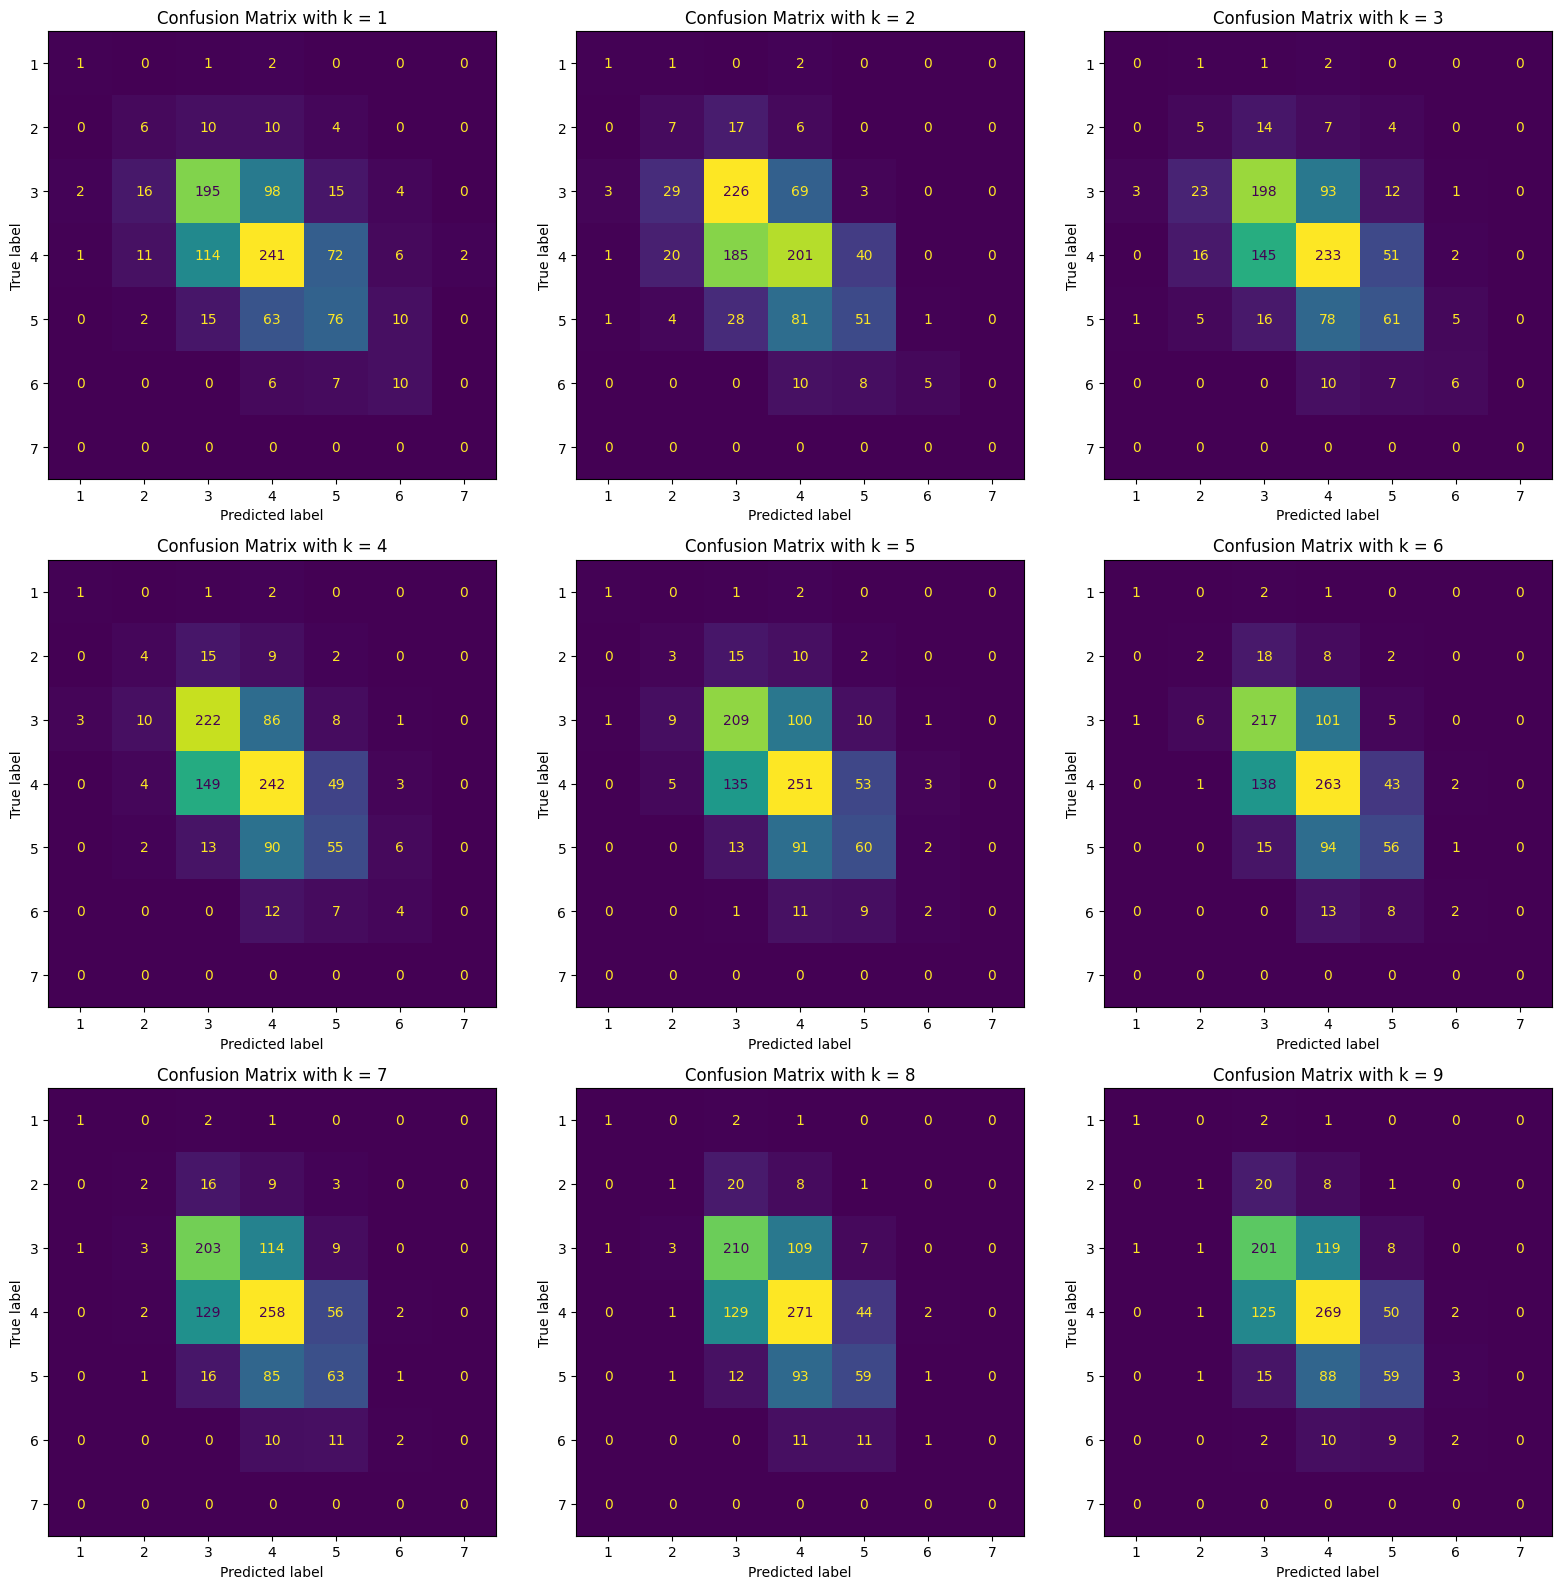

In [16]:
preds = cp.zeros_like(y_test_cp)
y_test = y_test_cp.get()
accuracies = []
exec_times = []
k_values = range(1, 10)

fig, axs = plt.subplots(3, 3, figsize=(16, 16))
axs = axs.ravel()

for K_VALUE in k_values:
    ax = axs[K_VALUE - 1]

    start_time = time.time()

    # Take nearest k train samples' labels for each test sample
    nearest_labels = sorted_labels[:, :K_VALUE]

    # Compute mode for each test sample on cupy
    preds_res = stats.mode(nearest_labels.get(), keepdims=True, axis=1)
    preds = np.array(preds_res)[0, ...]

    exec_times.append(time.time() - start_time)

    # Confusion matrix
    cm = confusion_matrix(y_test, preds, labels=classes)

    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix with k = {K_VALUE}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")


    accuracies.append(np.sum(np.trace(cm)) / len(preds) * 100)

plt.tight_layout()
plt.show()

In [17]:
# Average total execution time of kNN
total_exec_times = [t + dists_time for t in exec_times]
print(f"Execution time on GPU: {np.mean(total_exec_times):.6f} " + u"\u00B1" + f" {np.std(total_exec_times):.6f} s")

Execution time on GPU: 1.045244 ± 0.000280 s


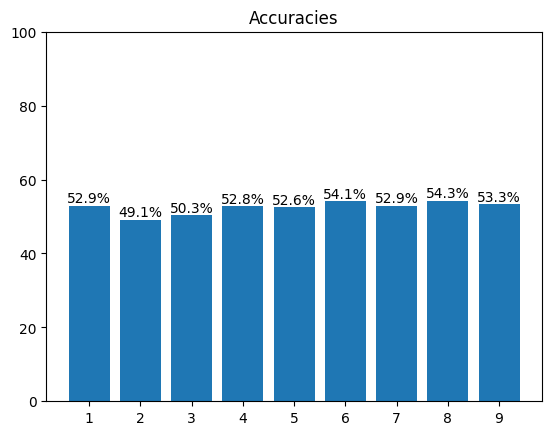

In [18]:
# Accuracies
accuracies_str = [f"{acc:.1f}%" for acc in accuracies]
fig, ax = plt.subplots()
bars = ax.bar(k_values, accuracies)
ax.bar_label(bars, labels=accuracies_str)
plt.title('Accuracies')
plt.xticks(k_values)
_, _ = plt.ylim((0,100))